In [1]:
import numpy as np
import sys
import time
import yaml
import pickle


from pydrake.all import (
                         Hyperellipsoid,
                         RandomGenerator,
                         Point,
                         GurobiSolver,
                         MosekSolver,
                         MathematicalProgram)
from pydrake.geometry.optimization import (
    HPolyhedron,
    LoadIrisRegionsYamlFile,
    SaveIrisRegionsYamlFile,
    )
import pydrake.math as pm
import pydot
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42  # Use TrueType (Type 42) fonts
matplotlib.rcParams['ps.fonttype'] = 42  # Ensures consistency for PS output

In [ ]:
# experiment_name = "fast_parameters_initial"
# experiment_name = "precise_parameters_initial"
experiment_name = "precise_parameters_fewer_zo_particles"

with open("logs/" + experiment_name + "/results.pkl", 'rb') as f:
    results = pickle.load(f)

In [6]:
results

{'algs': ['ray', 'greedy', 'zo'],
 'iris_times': array([[1.79999948, 2.1205647 , 2.38086009, 2.1445291 , 1.60622931,
         2.16241121, 1.93119168, 1.95822477, 1.78791451, 2.06678987],
        [0.67171049, 0.6883812 , 0.76351285, 0.71402097, 0.68916273,
         0.72565579, 0.73435068, 0.6718173 , 0.66692615, 0.60920238],
        [2.58188725, 2.74304891, 2.61303973, 2.6621666 , 2.81183743,
         2.66485429, 2.60333157, 2.72274113, 2.75616789, 2.93477321]]),
 'optimizer_times': array([[0.00031341, 0.00035875, 0.00036309, 0.00035378, 0.00031955,
         0.00030714, 0.0003309 , 0.00031555, 0.00032532, 0.00032315],
        [0.00036107, 0.00037985, 0.00038761, 0.00037291, 0.00038351,
         0.0003787 , 0.00041622, 0.00034806, 0.0003495 , 0.00036729],
        [0.00067711, 0.00066113, 0.00065547, 0.00070366, 0.00073373,
         0.00071186, 0.0007047 , 0.00067083, 0.00080868, 0.00081791]]),
 'num_faces': array([[14.42857143, 14.85714286, 14.57142857, 14.        , 14.14285714,
        

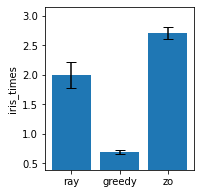

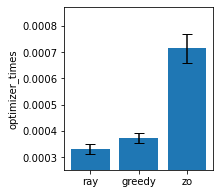

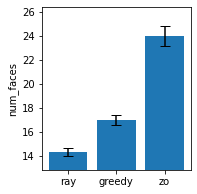

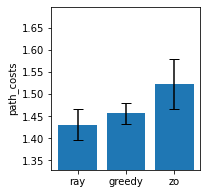

In [21]:
width = 4*2/3
# width = 4*2/3
height = 3
font_size = 13
axis_font_size = 11
linewidth = 2
labelpad = 5
markersizes=[5, 10]


for key in results.keys():
    if not key == "algs":
        plt.figure(figsize=(width, height))
        std = np.std(results[key], axis=1)
        plt.bar(results["algs"], np.mean(results[key], axis=1), yerr=std, capsize=5)
        plt.ylabel(key)

        y_min = np.min(results[key]) - np.max(std)
        y_max = np.max(results[key]) + np.max(std)
        padding = 0.001 * (y_max - y_min)  # 10% of the data range
        plt.ylim(y_min - padding, y_max + padding)


In [10]:
std

array([0.0349377 , 0.02328908, 0.05574532])

In [13]:
results[key]

array([[1.79999948, 2.1205647 , 2.38086009, 2.1445291 , 1.60622931,
        2.16241121, 1.93119168, 1.95822477, 1.78791451, 2.06678987],
       [0.67171049, 0.6883812 , 0.76351285, 0.71402097, 0.68916273,
        0.72565579, 0.73435068, 0.6718173 , 0.66692615, 0.60920238],
       [2.58188725, 2.74304891, 2.61303973, 2.6621666 , 2.81183743,
        2.66485429, 2.60333157, 2.72274113, 2.75616789, 2.93477321]])

In [15]:
np. min(results[key])

0.6092023849487305